# Public Wolffia Reviewed Marker Panel v1 Scoring

## tl;dr

This notebook scores the four public Waus8730 Wolffia runs using the frozen reviewed native marker panel v1. The v1 panel is derived from the manual review recommendations and is the current best Wolffia-native marker panel for future dataset scoring.

Executed result summary:

- 60 reviewed marker-program rows were retained.
- The panel contains 47 reviewed core markers, 9 reviewed supporting markers, and 4 reviewed unknown-watchlist markers.
- All reviewed v1 panel genes were present in the public Waus8730 expression matrix.
- 11,084 public Wolffia cells were scored across four runs.
- Dawn-group cells were higher for photosynthesis/light harvesting, carbon fixation/assimilation, and chloroplast gene expression/plastid translation.
- Dusk-group cells were higher for nutrient transport, RNA-binding/regulatory, and stress/chaperone response.

The reviewed v1 panel should be treated as the current best Wolffia-native scoring reference, while still remaining open to future biological revision.

## Context & Methods

The reviewed marker panel v1 keeps rows recommended as `keep`, `maybe`, or `unknown_interesting` from the manual review recommendation table. It assigns those rows to:

- `reviewed_core`
- `reviewed_supporting`
- `reviewed_unknown_watchlist`

For each program, this notebook calculates the mean normalized/log1p expression of all v1 panel genes present in the Waus8730 matrix. These scores are exploratory program scores, not hard cell-type labels.

In [1]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import anndata as ad

warnings.filterwarnings("ignore", category=FutureWarning)
sns.set_theme(style="whitegrid", context="notebook")

REPO_ROOT = Path.cwd().resolve()
while REPO_ROOT.name == "notebooks" or not (REPO_ROOT / "data" / "metadata").exists():
    if REPO_ROOT.parent == REPO_ROOT:
        raise RuntimeError("Could not locate repository root")
    REPO_ROOT = REPO_ROOT.parent

SSD_ROOT = Path("/Volumes/LaCie/wolffia_single_cell")
PROCESSED_DIR = SSD_ROOT / "results" / "processed_h5ad"
MODEL_DIR = SSD_ROOT / "results" / "model_application"

PANEL = REPO_ROOT / "data" / "metadata" / "wolffia_reviewed_native_marker_panel_v1.csv"
OUT_META = REPO_ROOT / "data" / "metadata"
OUT_FIG = REPO_ROOT / "figures" / "wolffia_reviewed_marker_panel_v1"
OUT_META.mkdir(parents=True, exist_ok=True)
OUT_FIG.mkdir(parents=True, exist_ok=True)

RUN_METADATA = {
    "SRR29417746": {"timepoint": "dawn", "replicate": "dawn_1"},
    "SRR29417745": {"timepoint": "dawn", "replicate": "dawn_2"},
    "SRR29417744": {"timepoint": "dusk", "replicate": "dusk_1"},
    "SRR29417743": {"timepoint": "dusk", "replicate": "dusk_2"},
}
RUNS = list(RUN_METADATA)
print("Repository:", REPO_ROOT)
print("Panel:", PANEL)

Repository: /Users/bella/Documents/Wolffia Single-Cell Atlas Pipeline Before the Data Arrive
Panel: /Users/bella/Documents/Wolffia Single-Cell Atlas Pipeline Before the Data Arrive/data/metadata/wolffia_reviewed_native_marker_panel_v1.csv


## Load reviewed panel and public data

In [2]:
panel = pd.read_csv(PANEL)
print("Reviewed panel rows:", len(panel))
print(panel["reviewed_panel_tier"].value_counts().to_string())
panel.groupby(["native_program_name", "reviewed_panel_tier"]).size().unstack(fill_value=0)

Reviewed panel rows: 60
reviewed_panel_tier
reviewed_core                 47
reviewed_supporting            9
reviewed_unknown_watchlist     4


reviewed_panel_tier,reviewed_core,reviewed_supporting,reviewed_unknown_watchlist
native_program_name,,,
Carbon fixation / assimilation,7,1,0
Chloroplast gene expression / plastid translation,7,1,0
Ion / water balance,6,1,0
Lipid / surface / cell-wall biology,6,2,0
Nutrient transport,4,1,0
Photosynthesis / light harvesting,8,0,0
RNA-binding / regulatory,3,0,0
Stress / chaperone response,6,2,0
Unknown high-ranking marker,0,1,4


In [3]:
adatas = []
for run in RUNS:
    h5ad = PROCESSED_DIR / f"{run}_normalized_log1p.h5ad"
    pred = MODEL_DIR / run / "combined_leaf_root_predictions.csv"
    sample = ad.read_h5ad(h5ad)
    sample.obs_names = [f"{run}_{bc}" for bc in sample.obs_names.astype(str)]
    sample.obs["run"] = run
    sample.obs["timepoint"] = RUN_METADATA[run]["timepoint"]
    sample.obs["replicate"] = RUN_METADATA[run]["replicate"]

    predictions = pd.read_csv(pred)
    predictions.index = [f"{run}_{bc}" for bc in predictions["cell_id"].astype(str)]
    sample.obs = sample.obs.join(predictions[["final_label", "final_interpretation_status"]], how="left")
    adatas.append(sample)

combined = ad.concat(adatas, join="inner", merge="same", label="run_from_concat", keys=RUNS)
combined.obs["final_label"] = combined.obs["final_label"].fillna("missing_prediction")
combined.obs["final_interpretation_status"] = combined.obs["final_interpretation_status"].fillna("missing_prediction")
print(combined)

AnnData object with n_obs × n_vars = 11084 × 15080
    obs: 'run', 'timepoint', 'replicate', 'final_label', 'final_interpretation_status', 'run_from_concat'
    var: 'feature_type'


## Score reviewed v1 programs

In [4]:
def mean_expression_score(adata, genes):
    present = [g for g in genes if g in adata.var_names]
    if not present:
        return np.full(adata.n_obs, np.nan), present
    X = adata[:, present].X
    if hasattr(X, "toarray"):
        return np.asarray(X.mean(axis=1)).ravel(), present
    return np.asarray(X).mean(axis=1), present

program_lookup = panel.drop_duplicates("native_program_id").set_index("native_program_id")["native_program_name"].to_dict()
coverage_rows = []

for program_id, sub in panel.groupby("native_program_id"):
    genes = sorted(sub["waus8730_gene_id"].dropna().unique())
    scores, present = mean_expression_score(combined, genes)
    combined.obs[f"reviewed_v1_score_{program_id}"] = scores
    coverage_rows.append({
        "native_program_id": program_id,
        "native_program_name": program_lookup[program_id],
        "panel_genes": len(genes),
        "genes_present_in_matrix": len(present),
        "coverage_fraction": len(present) / len(genes),
        "reviewed_core": (sub["reviewed_panel_tier"] == "reviewed_core").sum(),
        "reviewed_supporting": (sub["reviewed_panel_tier"] == "reviewed_supporting").sum(),
        "reviewed_unknown_watchlist": (sub["reviewed_panel_tier"] == "reviewed_unknown_watchlist").sum(),
    })

coverage = pd.DataFrame(coverage_rows).sort_values("panel_genes", ascending=False)
coverage_path = OUT_META / "wolffia_reviewed_native_marker_panel_v1_gene_coverage.csv"
coverage.to_csv(coverage_path, index=False)
print("Wrote:", coverage_path)
coverage

Wrote: /Users/bella/Documents/Wolffia Single-Cell Atlas Pipeline Before the Data Arrive/data/metadata/wolffia_reviewed_native_marker_panel_v1_gene_coverage.csv


,native_program_id,native_program_name,panel_genes,genes_present_in_matrix,coverage_fraction,reviewed_core,reviewed_supporting,reviewed_unknown_watchlist
0,carbon_fixation_assimilation,Carbon fixation / assimilation,8,8,1.0,7,1,0
1,chloroplast_gene_expression,Chloroplast gene expression / plastid translation,8,8,1.0,7,1,0
3,lipid_surface_cell_wall,Lipid / surface / cell-wall biology,8,8,1.0,6,2,0
5,photosynthesis_light_harvesting,Photosynthesis / light harvesting,8,8,1.0,8,0,0
7,stress_chaperone_response,Stress / chaperone response,8,8,1.0,6,2,0
2,ion_water_balance,Ion / water balance,7,7,1.0,6,1,0
4,nutrient_transport,Nutrient transport,5,5,1.0,4,1,0
8,unknown_high_marker,Unknown high-ranking marker,5,5,1.0,0,1,4
6,rna_binding_regulatory,RNA-binding / regulatory,3,3,1.0,3,0,0


In [5]:
score_cols = [c for c in combined.obs.columns if c.startswith("reviewed_v1_score_")]
summary_rows = []
for group_cols in [["run"], ["timepoint"], ["final_label"], ["timepoint", "final_label"]]:
    for group_key, group_df in combined.obs.groupby(group_cols, observed=True):
        if not isinstance(group_key, tuple):
            group_key = (group_key,)
        base = dict(zip(group_cols, group_key))
        for col in score_cols:
            program_id = col.replace("reviewed_v1_score_", "")
            summary_rows.append({
                "grouping": "+".join(group_cols),
                **base,
                "native_program_id": program_id,
                "native_program_name": program_lookup.get(program_id, program_id),
                "n_cells": len(group_df),
                "mean_score": group_df[col].mean(),
                "median_score": group_df[col].median(),
            })

summary = pd.DataFrame(summary_rows)
summary_path = OUT_META / "wolffia_reviewed_native_marker_panel_v1_score_summary.csv"
summary.to_csv(summary_path, index=False)
print("Wrote:", summary_path)
summary.query("grouping == 'timepoint'").head(12)

Wrote: /Users/bella/Documents/Wolffia Single-Cell Atlas Pipeline Before the Data Arrive/data/metadata/wolffia_reviewed_native_marker_panel_v1_score_summary.csv


,grouping,run,native_program_id,native_program_name,n_cells,mean_score,median_score,timepoint,final_label
36,timepoint,NaN,carbon_fixation_assimilation,Carbon fixation / assimilation,5532,3.659207,3.687262,dawn,NaN
37,timepoint,NaN,chloroplast_gene_expression,Chloroplast gene expression / plastid translation,5532,2.279707,2.050526,dawn,NaN
38,timepoint,NaN,ion_water_balance,Ion / water balance,5532,1.567398,1.516263,dawn,NaN
39,timepoint,NaN,lipid_surface_cell_wall,Lipid / surface / cell-wall biology,5532,1.039560,0.938869,dawn,NaN
40,timepoint,NaN,nutrient_transport,Nutrient transport,5532,0.667391,0.414763,dawn,NaN
41,timepoint,NaN,photosynthesis_light_harvesting,Photosynthesis / light harvesting,5532,3.789370,3.820998,dawn,NaN
42,timepoint,NaN,rna_binding_regulatory,RNA-binding / regulatory,5532,1.201947,1.160463,dawn,NaN
43,timepoint,NaN,stress_chaperone_response,Stress / chaperone response,5532,0.941641,0.930707,dawn,NaN
44,timepoint,NaN,unknown_high_marker,Unknown high-ranking marker,5532,1.223194,1.086774,dawn,NaN
45,timepoint,NaN,carbon_fixation_assimilation,Carbon fixation / assimilation,5552,3.465518,3.556155,dusk,NaN


## Results: score heatmaps

Wrote: /Users/bella/Documents/Wolffia Single-Cell Atlas Pipeline Before the Data Arrive/figures/wolffia_reviewed_marker_panel_v1/reviewed_v1_score_heatmaps.png


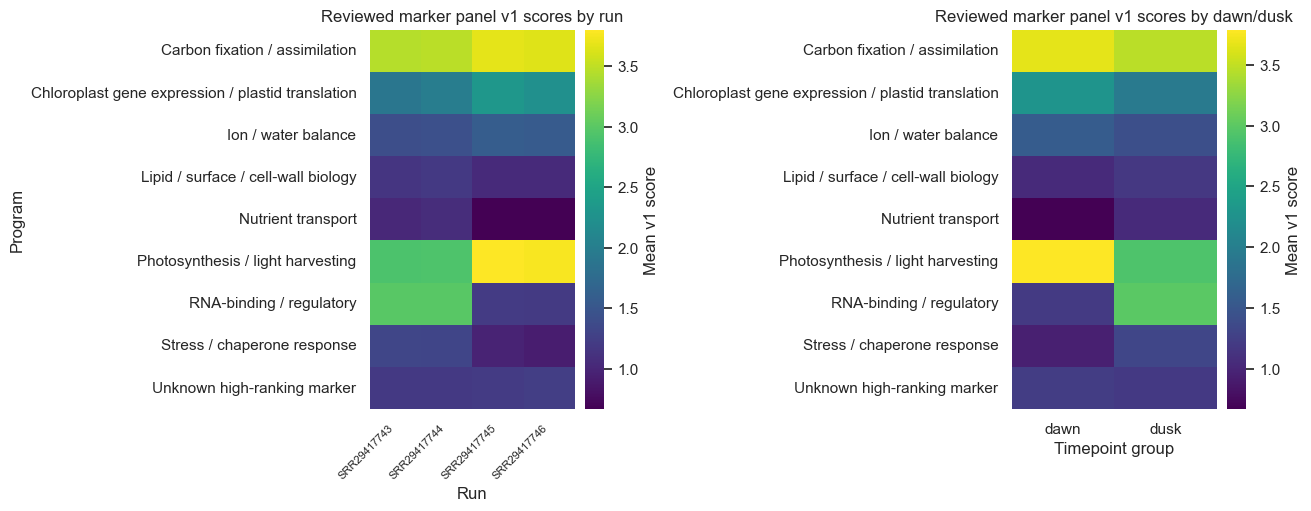

In [6]:
run_heatmap = summary.query("grouping == 'run'").pivot(index="native_program_name", columns="run", values="mean_score")
timepoint_heatmap = summary.query("grouping == 'timepoint'").pivot(index="native_program_name", columns="timepoint", values="mean_score")
label_heatmap = summary.query("grouping == 'final_label'").pivot(index="native_program_name", columns="final_label", values="mean_score")

fig, axes = plt.subplots(1, 2, figsize=(13, 5), constrained_layout=True)
sns.heatmap(run_heatmap, cmap="viridis", ax=axes[0], cbar_kws={"label": "Mean v1 score"})
axes[0].set_title("Reviewed marker panel v1 scores by run")
axes[0].set_xlabel("Run")
axes[0].set_ylabel("Program")
axes[0].tick_params(axis="x", labelrotation=45, labelsize=8)
for label in axes[0].get_xticklabels():
    label.set_ha("right")

sns.heatmap(timepoint_heatmap, cmap="viridis", ax=axes[1], cbar_kws={"label": "Mean v1 score"})
axes[1].set_title("Reviewed marker panel v1 scores by dawn/dusk")
axes[1].set_xlabel("Timepoint group")
axes[1].set_ylabel("")
fig_path = OUT_FIG / "reviewed_v1_score_heatmaps.png"
fig.savefig(fig_path, dpi=180, bbox_inches="tight")
print("Wrote:", fig_path)
plt.show()

Wrote: /Users/bella/Documents/Wolffia Single-Cell Atlas Pipeline Before the Data Arrive/figures/wolffia_reviewed_marker_panel_v1/reviewed_v1_scores_by_transfer_label.png


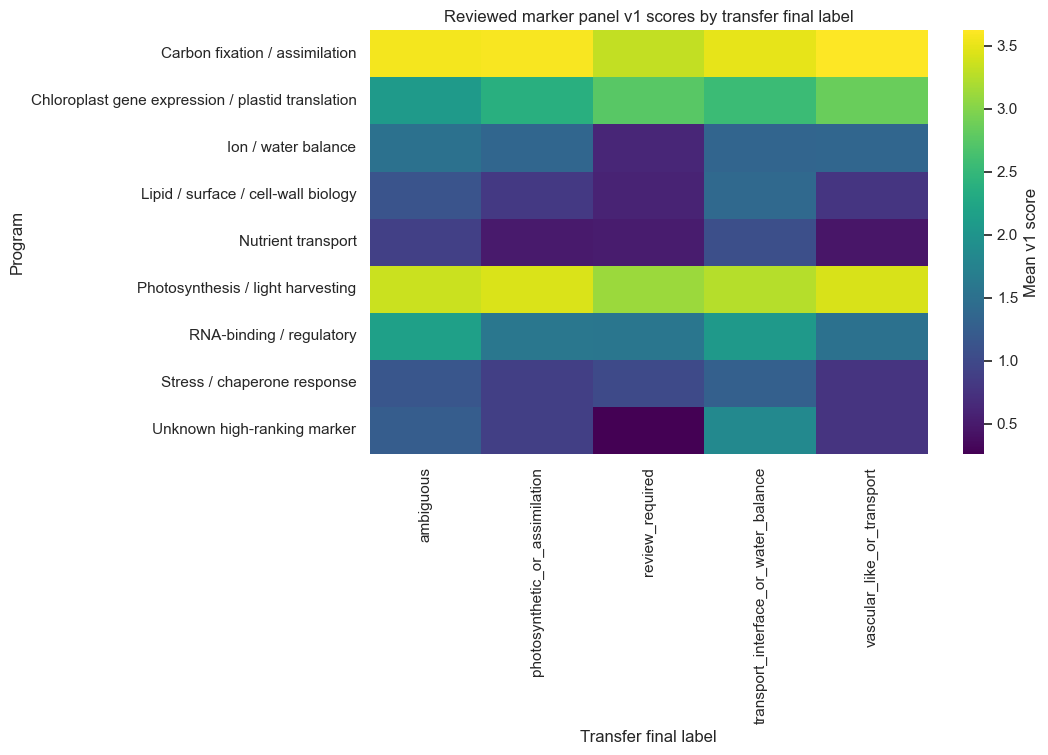

In [7]:
fig, ax = plt.subplots(figsize=(9, 5.5))
sns.heatmap(label_heatmap, cmap="viridis", ax=ax, cbar_kws={"label": "Mean v1 score"})
ax.set_title("Reviewed marker panel v1 scores by transfer final label")
ax.set_xlabel("Transfer final label")
ax.set_ylabel("Program")
fig_path = OUT_FIG / "reviewed_v1_scores_by_transfer_label.png"
fig.savefig(fig_path, dpi=180, bbox_inches="tight")
print("Wrote:", fig_path)
plt.show()

## Takeaways

In [8]:
for program_id, name in program_lookup.items():
    sub = summary.query("grouping == 'timepoint' and native_program_id == @program_id")
    vals = dict(zip(sub["timepoint"], sub["mean_score"]))
    dawn = vals.get("dawn", np.nan)
    dusk = vals.get("dusk", np.nan)
    print(f"{name}: dawn={dawn:.4f}, dusk={dusk:.4f}, dawn-minus-dusk={dawn-dusk:.4f}")
print(f"Total cells scored: {combined.n_obs:,}")
print(f"Reviewed v1 panel rows: {len(panel):,}")
print(f"Minimum marker coverage: {coverage['coverage_fraction'].min():.3f}")

Carbon fixation / assimilation: dawn=3.6592, dusk=3.4655, dawn-minus-dusk=0.1937
Chloroplast gene expression / plastid translation: dawn=2.2797, dusk=1.9385, dawn-minus-dusk=0.3412
Ion / water balance: dawn=1.5674, dusk=1.4208, dawn-minus-dusk=0.1466
Lipid / surface / cell-wall biology: dawn=1.0396, dusk=1.1679, dawn-minus-dusk=-0.1283
Nutrient transport: dawn=0.6674, dusk=1.0411, dawn-minus-dusk=-0.3737
Photosynthesis / light harvesting: dawn=3.7894, dusk=2.9205, dawn-minus-dusk=0.8689
RNA-binding / regulatory: dawn=1.2019, dusk=2.9863, dawn-minus-dusk=-1.7843
Stress / chaperone response: dawn=0.9416, dusk=1.3180, dawn-minus-dusk=-0.3764
Unknown high-ranking marker: dawn=1.2232, dusk=1.1875, dawn-minus-dusk=0.0357
Total cells scored: 11,084
Reviewed v1 panel rows: 60
Minimum marker coverage: 1.000


## Interpretation

The reviewed marker panel v1 should be treated as the current best Wolffia-native scoring panel. For future salt-stress data, this panel can be used to compare program scores across condition, sample, replicate, and cluster.